Are there missing values in training data: False
Are there missing values in test data: False
Number of unique classes: 26


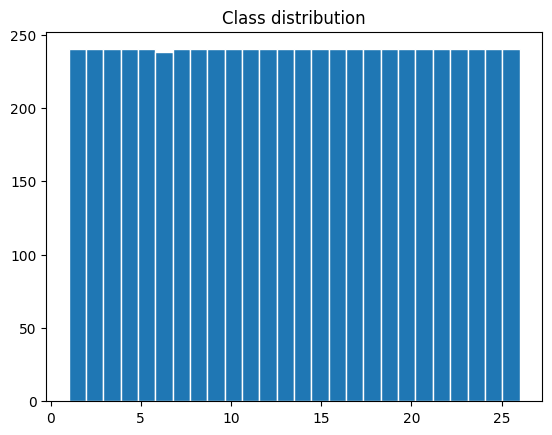

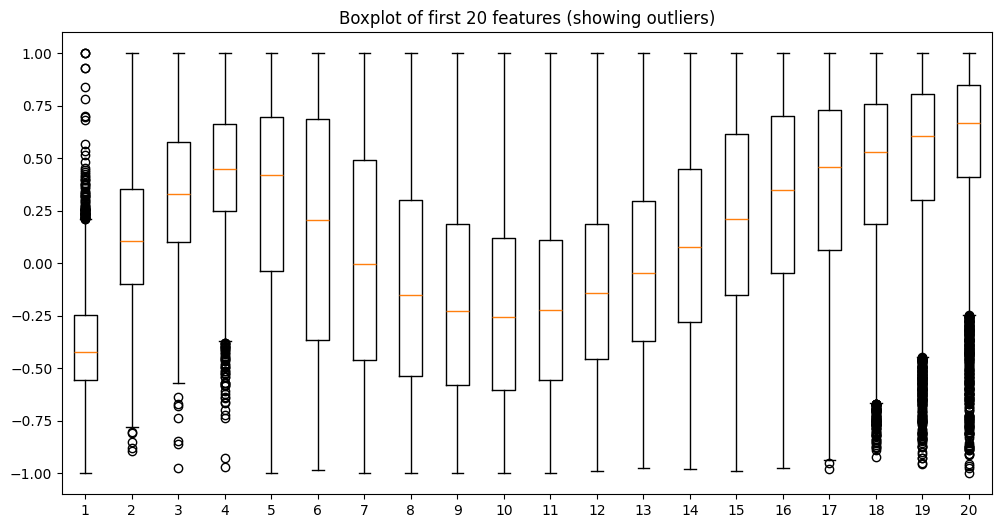

In [37]:
import pandas as pd
from matplotlib import pyplot as plt

# Loading training and test datasets
train_data = pd.read_csv("isolet/isolet1+2+3+4.data", header= None)
test_data = pd.read_csv("isolet/isolet5.data", header = None)

# According to dataset documentation there are no missing values.
# This was additionally verified with code below.
print("Are there missing values in training data:", train_data.isna().any().any())
print("Are there missing values in test data:", test_data.isna().any().any())

# Separating train and test data (last column represents the class label).
x_train = train_data.drop(617, axis = 1)
y_train = train_data[617]

x_test = test_data.drop(617, axis = 1)
y_test = test_data[617]

# Check unique class labels (should be 26 classes for letters A–Z)
print("Number of unique classes:", len(y_train.unique()))

# Dataset is balanced, so no resampling is needed.
plt.hist(y_train, edgecolor = 'white', bins = 26)
plt.title("Class distribution")
plt.show()

# Boxplot for detecting potential outliers
sample_features = x_train.iloc[:, :20]
plt.figure(figsize=(12,6))
plt.boxplot(sample_features.values)
plt.title("Boxplot of first 20 features (showing outliers)")
plt.show()

# Feature scaling using StandardScaler.
# Although original features are already within the range [-1, 1],
# standardization is applied to center the data.
# This could help distance-based algorithms such as KNN and SVC.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

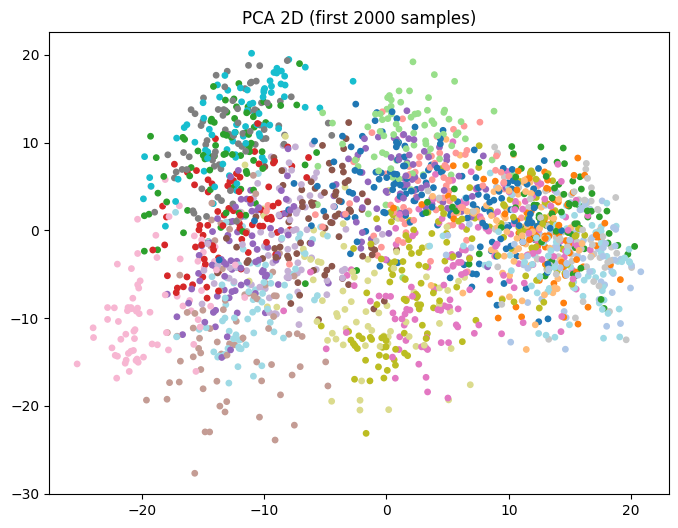

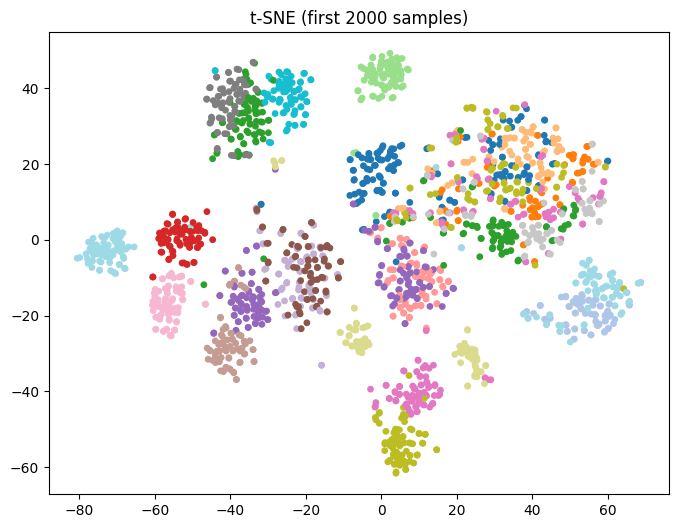

In [38]:
# This section visualizes data using PCA and t-SNE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Visualization of data distribution using PCA with 2 components
x_sample = x_train[:2000]
y_sample = y_train[:2000]

pca_2d = PCA(n_components=2)
pca_2d.fit(x_sample)
x_2d = pca_2d.transform(x_sample)

plt.figure(figsize=(8,6))
plt.scatter(x_2d[:,0], x_2d[:,1], c=y_sample, cmap='tab20', s=15)
plt.title("PCA 2D (first 2000 samples)")
plt.show()

# t-SNE visualisation od data subset
tsne = TSNE(n_components=2, random_state=123)
x_tsne = tsne.fit_transform(x_sample)  

plt.figure(figsize=(8,6))
plt.scatter(x_tsne[:,0], x_tsne[:,1], c=y_sample, cmap='tab20', s=15)
plt.title("t-SNE (first 2000 samples)")
plt.show()

[0.54573663 0.67034241 0.73389222 0.77517682 0.80593743 0.83033081
 0.84947567]


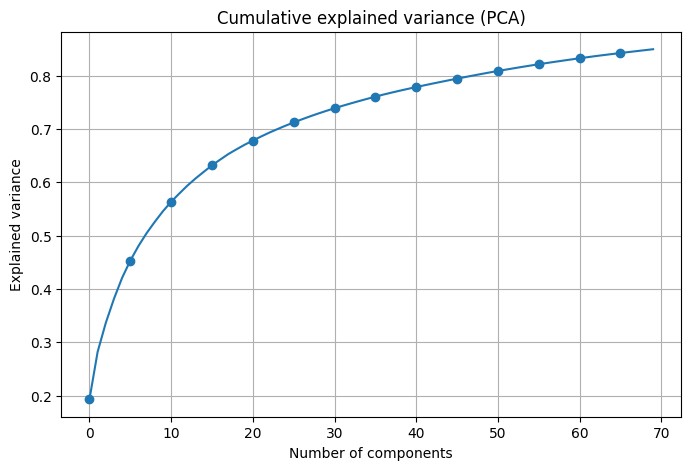

In [39]:
# In this section we analyze PCA and examine how much of the data
# is captured by its main components.
# We also perform feature selection using the Random Forest algorithm
# to identify the most important features and put them in another subset.

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# We are analysing 70 components of PCA 
pca = PCA(n_components=70)
pca.fit(x_train)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Cumulative explained variance at 10, 20, 30, ..., 70 components
print(cumulative_variance[9::10])

# Based on this graph we choose to use 50 components in our experiments,
# since they explaine around 80% of the variance.
# Adding more components results in only small gains,
# so selecting 50 components is a balance between good data coverage
# and lower dimensionality.
plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o', markevery=5)
plt.title('Cumulative explained variance (PCA)')
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.grid(True)
#plt.savefig("explained_variance.png", dpi=300, bbox_inches='tight')
plt.show()

# Random Forest is used to estimate feature importance.
# Based on these results we will create subsets of features
# and evaluate how the number of selected features affects performance.
rf = RandomForestClassifier(random_state=123)
rf.fit(x_train, y_train)

features = rf.feature_importances_
sorted_features = np.argsort(features)[::-1]

# We tested different numbers of selected features:
#   - k = 50  -> accuracy = 0.89
#   - k = 100 -> accuracy = 0.91
#   - k = 150 -> accuracy = 0.9358
#   - k = 200 -> accuracy = 0.9358
#   - all features - accuracy = 0.94
# Based on the results, we select the top 150 features for our experiments.
# This subset achieves performance very close to using all features,
# while significantly reducing dimensionality.
top_k = 150
selected_features = sorted_features[:top_k]

# PCA and feature selection data that will be used later for models
pca = PCA(n_components=50)
pca.fit(x_train)
x_train_PCA = pca.transform(x_train)
x_test_PCA = pca.transform(x_test)

x_train_fs = x_train[:, selected_features]
x_test_fs = x_test[:, selected_features]

In [40]:
# In this section we intialize all models that will be used in the experiments.

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

# Grid search for hyperparameter tuning of Decision Tree
# params_grid = { 'criterion' : ['gini', 'entropy'],
#                 'max_depth' : [10, 15, 20],
#                 'min_samples_split' : [2, 10, 15],
#                 'min_samples_leaf' : [2, 5, 7]}
# dtc_estimator = GridSearchCV(DecisionTreeClassifier(random_state = 123), params_grid)

# Grid search for hyperparameter tuning of KNN
# params = { 'n_neighbors' : [5, 7, 9, 11],
#            'weights' : ['uniform', 'distance'],
#            'p' : [1,2]}
# knn_estimator = GridSearchCV(KNeighborsClassifier(), params)

dtc = DecisionTreeClassifier(
    criterion = 'entropy', 
    max_depth = 15, 
    min_samples_split = 15, 
    min_samples_leaf = 5, 
    random_state=123)

random_forest = RandomForestClassifier(
    n_estimators=100, 
    random_state=123)

knn = KNeighborsClassifier(
    n_neighbors = 9, 
    weights = 'distance',
    p=2)

svc = SVC(
    kernel = 'rbf', 
    C = 10)

gbc = GradientBoostingClassifier(
    n_estimators = 30, 
    random_state = 123)



In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns

def save_model(model, name=None):
    
    model_type = type(model).__name__
    dir_path = os.path.join("models", model_type)
    
    os.makedirs(dir_path, exist_ok=True)

    if name is None:
        time_created = time.strftime("%Y_%m_%d-%H_%M_%S")
        name = f"{time_created}.pkl"
    else:
        name = f"{name}.pkl"
        
    file_path = os.path.join(dir_path, name)
    
    with open(file_path, 'wb') as file:
        joblib.dump(model, file)

    print(f"Model saved to: {file_path}")
 
def load_model(file_path):
    with open(file_path, 'rb') as file:
        model = joblib.load(file)
    return model
    
# Function for training and evaluating model.
# Prints accuracy, optional detailed report and training time.
# Parameters:
#    - full_report  -> if True, prints classification report and confusion matrix
#    - save         -> if True, saves the trained model to disk
#    - save_name    -> custom name for saved model file
def test_model(
    model, 
    x_train, y_train, 
    x_test, y_test, 
    full_report = False, 
    save = False,
    save_name = None):

    start = time.time()
    model.fit(x_train, y_train)
    end = time.time()

    y_pred_train = model.predict(x_train)
    acc_train = accuracy_score(y_train, y_pred_train)
    
    y_pred_test = model.predict(x_test)
    acc_test = accuracy_score(y_test, y_pred_test)

    print(f"Train accuracy: {acc_train*100:.2f}%  Test accuracy: {acc_test*100:.2f}%")
    print(f"Training time: {end - start:.2f}s\n")

    if full_report:
        print(classification_report(y_test, y_pred_test))
        cm = confusion_matrix(y_test, y_pred_test)

        plt.figure()
        sns.heatmap(cm, annot=False)
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

    if save:
        save_model(model, save_name)


In [50]:
# This section evaluates classification models using three different
# dataset representations:
#    - x_train, x_test          -> original dataset (all features)
#    - x_train_PCA, x_test_PCA  -> PCA dataset
#    - x_train_fs, x_test_fs    -> feature selection subset

models = [
    dtc,
    random_forest,
    knn,
    svc,
    gbc
]

for model in models:
    print(f"\n===== {type(model).__name__} =====")

    # Regular
    print("* Regular")
    test_model(model, x_train, y_train, x_test, y_test)
    
    # PCA
    print("* PCA")
    test_model(model, x_train_PCA, y_train, x_test_PCA, y_test)
    
    # Feature selected
    print("* Feature selected")
    test_model(model, x_train_fs, y_train, x_test_fs, y_test)



===== DecisionTreeClassifier =====
* Regular
Train accuracy: 93.19%  Test accuracy: 82.81%
Training time: 12.10s

* PCA
Train accuracy: 86.84%  Test accuracy: 68.38%
Training time: 1.49s

* Feature selected
Train accuracy: 92.63%  Test accuracy: 82.68%
Training time: 2.71s


===== RandomForestClassifier =====
* Regular
Train accuracy: 100.00%  Test accuracy: 93.97%
Training time: 18.40s

* PCA
Train accuracy: 100.00%  Test accuracy: 90.57%
Training time: 7.14s

* Feature selected
Train accuracy: 100.00%  Test accuracy: 93.59%
Training time: 8.67s


===== KNeighborsClassifier =====
* Regular
Train accuracy: 100.00%  Test accuracy: 92.62%
Training time: 0.02s

* PCA
Train accuracy: 100.00%  Test accuracy: 90.83%
Training time: 0.01s

* Feature selected
Train accuracy: 100.00%  Test accuracy: 93.59%
Training time: 0.01s


===== SVC =====
* Regular
Train accuracy: 100.00%  Test accuracy: 96.41%
Training time: 5.75s

* PCA
Train accuracy: 99.97%  Test accuracy: 94.93%
Training time: 0.80s


Train accuracy: 93.19%  Test accuracy: 82.81%
Training time: 11.86s

              precision    recall  f1-score   support

         1.0       0.88      0.77      0.82        60
         2.0       0.76      0.78      0.77        60
         3.0       0.96      0.88      0.92        60
         4.0       0.79      0.83      0.81        60
         5.0       0.71      0.73      0.72        60
         6.0       0.83      0.90      0.86        60
         7.0       0.73      0.77      0.75        60
         8.0       0.88      0.98      0.93        60
         9.0       0.83      0.88      0.85        60
        10.0       0.86      0.70      0.77        60
        11.0       0.75      0.82      0.78        60
        12.0       0.87      0.90      0.89        60
        13.0       0.73      0.80      0.76        59
        14.0       0.77      0.67      0.71        60
        15.0       0.93      0.92      0.92        60
        16.0       0.63      0.68      0.66        60
        17.0

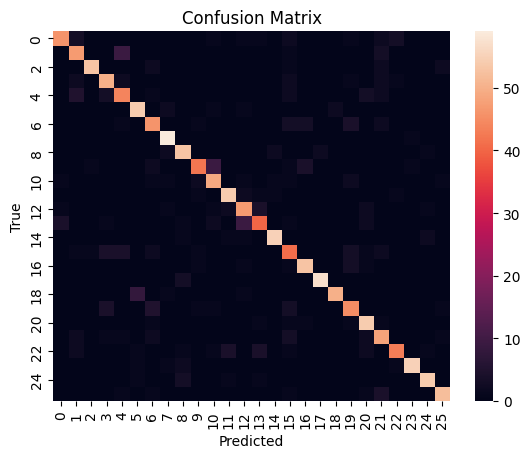

Train accuracy: 100.00%  Test accuracy: 96.41%
Training time: 7.12s

              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00        60
         2.0       0.91      0.88      0.90        60
         3.0       0.97      0.98      0.98        60
         4.0       0.97      0.93      0.95        60
         5.0       0.91      0.97      0.94        60
         6.0       0.95      0.98      0.97        60
         7.0       0.97      1.00      0.98        60
         8.0       1.00      1.00      1.00        60
         9.0       0.98      0.95      0.97        60
        10.0       1.00      1.00      1.00        60
        11.0       1.00      0.98      0.99        60
        12.0       1.00      1.00      1.00        60
        13.0       0.86      0.92      0.89        59
        14.0       0.93      0.83      0.88        60
        15.0       1.00      1.00      1.00        60
        16.0       0.95      0.93      0.94        60
        17.0

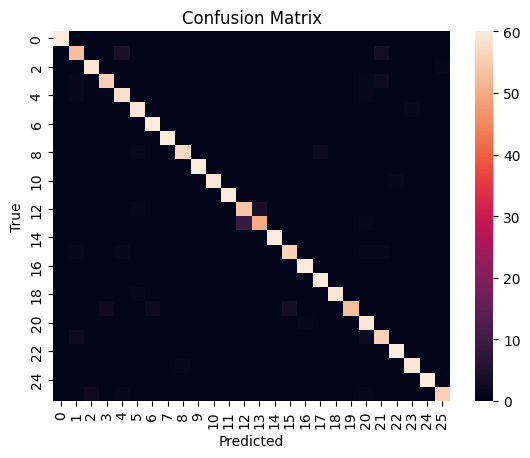

In [46]:
# Detailed evaluation of the best (SVM) and worst (DTC) performing models
# using full classification report and confusion matrix on the original dataset

test_model(dtc, x_train, y_train, x_test, y_test, full_report=True)
test_model(svc, x_train, y_train, x_test, y_test, full_report=True)

In [49]:
# Demonstration of loading a saved model and evaluating it

model = load_model("models/SVC/SVM_all_features.pkl")

y_pred_train = model.predict(x_train)
acc_train = accuracy_score(y_train, y_pred_train)

y_pred_test = model.predict(x_test)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Train accuracy: {acc_train*100:.2f}% Test accuracy: {acc_test*100:.2f}%")

Train accuracy: 100.00% Test accuracy: 96.41%
